In [85]:
import numpy as np
import matplotlib.pyplot as plt

In [86]:
s = np.linspace(0, 2 * np.pi, 100)
t = np.linspace(0, np.pi, 100)

x = np.outer(np.cos(s), np.sin(t))
y = np.outer(np.sin(s), np.sin(t))
z = np.outer(np.ones(np.size(s)), np.cos(t)) 
points_shape = x.shape

display(x)
display(y)
display(z)

array([[0.00000000e+00, 3.17279335e-02, 6.34239197e-02, ...,
        6.34239197e-02, 3.17279335e-02, 1.22464680e-16],
       [0.00000000e+00, 3.16640549e-02, 6.32962268e-02, ...,
        6.32962268e-02, 3.16640549e-02, 1.22218119e-16],
       [0.00000000e+00, 3.14726763e-02, 6.29136624e-02, ...,
        6.29136624e-02, 3.14726763e-02, 1.21479429e-16],
       ...,
       [0.00000000e+00, 3.14726763e-02, 6.29136624e-02, ...,
        6.29136624e-02, 3.14726763e-02, 1.21479429e-16],
       [0.00000000e+00, 3.16640549e-02, 6.32962268e-02, ...,
        6.32962268e-02, 3.16640549e-02, 1.22218119e-16],
       [0.00000000e+00, 3.17279335e-02, 6.34239197e-02, ...,
        6.34239197e-02, 3.17279335e-02, 1.22464680e-16]], shape=(100, 100))

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  2.01230991e-03,  4.02259358e-03, ...,
         4.02259358e-03,  2.01230991e-03,  7.76719002e-18],
       [ 0.00000000e+00,  4.01651695e-03,  8.02898960e-03, ...,
         8.02898960e-03,  4.01651695e-03,  1.55031043e-17],
       ...,
       [-0.00000000e+00, -4.01651695e-03, -8.02898960e-03, ...,
        -8.02898960e-03, -4.01651695e-03, -1.55031043e-17],
       [-0.00000000e+00, -2.01230991e-03, -4.02259358e-03, ...,
        -4.02259358e-03, -2.01230991e-03, -7.76719002e-18],
       [-0.00000000e+00, -7.77110244e-18, -1.55343800e-17, ...,
        -1.55343800e-17, -7.77110244e-18, -2.99951957e-32]],
      shape=(100, 100))

array([[ 1.        ,  0.99949654,  0.99798668, ..., -0.99798668,
        -0.99949654, -1.        ],
       [ 1.        ,  0.99949654,  0.99798668, ..., -0.99798668,
        -0.99949654, -1.        ],
       [ 1.        ,  0.99949654,  0.99798668, ..., -0.99798668,
        -0.99949654, -1.        ],
       ...,
       [ 1.        ,  0.99949654,  0.99798668, ..., -0.99798668,
        -0.99949654, -1.        ],
       [ 1.        ,  0.99949654,  0.99798668, ..., -0.99798668,
        -0.99949654, -1.        ],
       [ 1.        ,  0.99949654,  0.99798668, ..., -0.99798668,
        -0.99949654, -1.        ]], shape=(100, 100))

In [87]:
def plot_sphere(x: np.ndarray, y: np.ndarray, z: np.ndarray, A = np.identity(3)):
    points = np.column_stack([x.flatten(), y.flatten(), z.flatten()]) @ A
    x, y, z = points[:, 0].reshape(points_shape), points[:, 1].reshape(points_shape), points[:, 2].reshape(points_shape)

    fig = plt.figure()
    ax = fig.add_subplot(projection="3d")

    ax.plot_surface(x, y, z, alpha=0.4)
    ax.set_aspect('equal')

    plt.show()

In [88]:
def plot_sphere_with_eigen_vec(
        x: np.ndarray, 
        y: np.ndarray, 
        z: np.ndarray, 
        A: np.ndarray = np.identity(3),
):
    points = A @ np.vstack([x.flatten(), y.flatten(), z.flatten()])
    x, y, z = points[0].reshape(points_shape), points[1].reshape(points_shape), points[2].reshape(points_shape)
	
    U, S, _ = np.linalg.svd(A)

    eigen_x = U[:, 0] * S[0]
    eigen_y = U[:, 1] * S[1]
    eigen_z = U[:, 2] * S[2]

    fig = plt.figure()
    ax = fig.add_subplot(projection="3d")

    ax.quiver(0, 0, 0, *eigen_x, color="r")
    ax.quiver(0, 0, 0, *eigen_y, color="g")
    ax.quiver(0, 0, 0, *eigen_z, color="b")

    ax.plot_surface(x, y, z, alpha=0.4)
    ax.set_aspect('equal')
 
    plt.show()

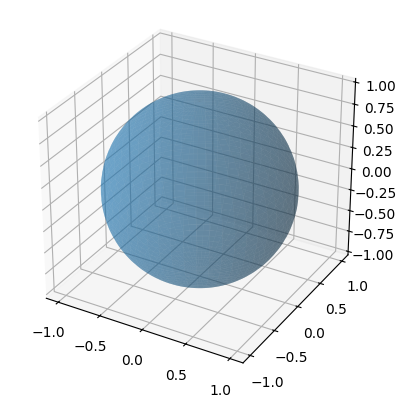

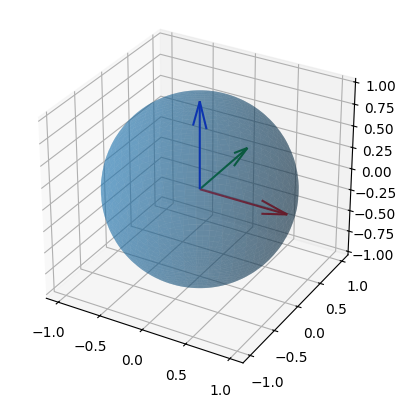

In [89]:
plot_sphere(x, y, z)
plot_sphere_with_eigen_vec(x, y, z)

In [90]:
A1 = np.array([
    [1, 0.1, 0],
    [0, 1, 0],
    [0, -0.9, 1.2],
])

A2 = np.array([
    [1, 0, 0.2],
    [0, 1.5, 0],
    [-0.2, 0, 1],
])

A3 = np.array([
    [0.5, 0, -0.5],
    [0, 1, 0],
    [0.5, 0, 1],
])

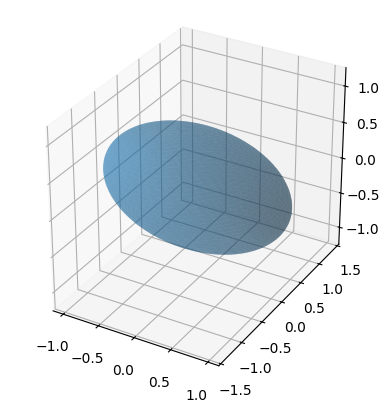

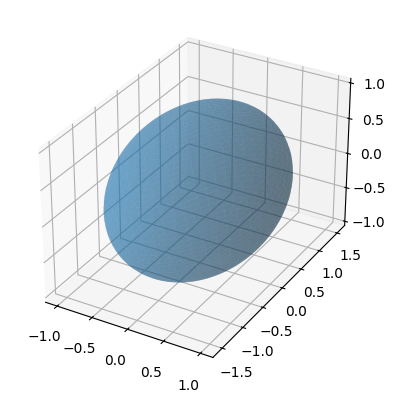

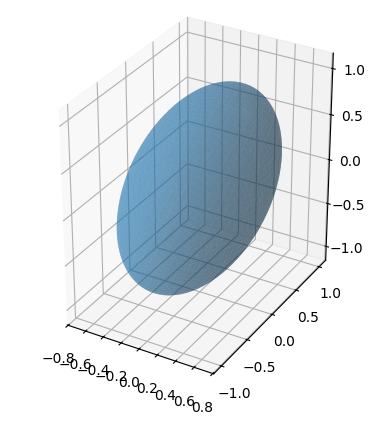

In [91]:
plot_sphere(x, y, z, A1)
plot_sphere(x, y, z, A2)
plot_sphere(x, y, z, A3)

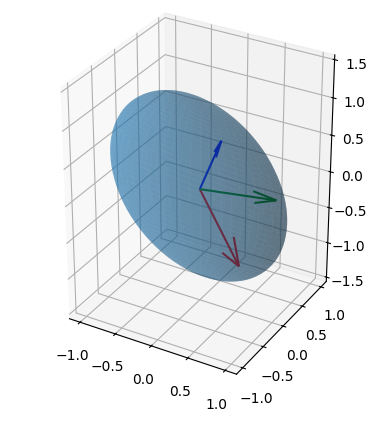

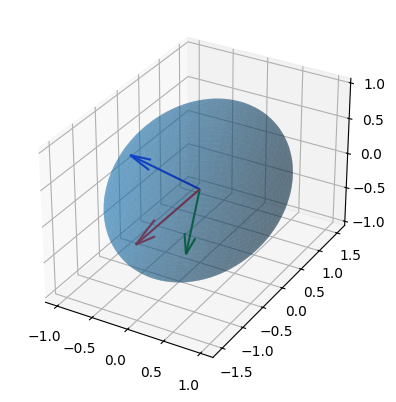

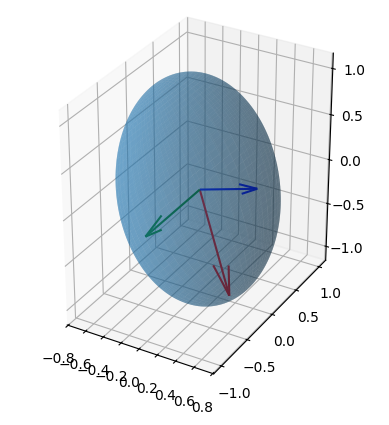

In [92]:
plot_sphere_with_eigen_vec(x, y, z, A1)
plot_sphere_with_eigen_vec(x, y, z, A2)
plot_sphere_with_eigen_vec(x, y, z, A3)